In [30]:
# import mitsuba
import math

from scipy import constants as const

# import drjit
import drjit as dr
import matplotlib.pyplot as plt
import numpy as np

import mitsuba as mi

# colocar el valor de spectral
mi.set_variant("cuda_ad_spectral")

from mitsuba import ScalarTransform4f as T


In [31]:
def load_sensor_spectral(
    r: float,
    phi: float,
    theta: float,
    wave_lengths: np.ndarray,
    sigma: float,
    k: float = 3,
    n_wavelents: int = 5,
):
    """
    Load a sensor with Gaussian response.

    Args:
        r (float): Radius of the sensor.
        phi (float): Azimuthal angle in degrees.
        theta (float): Polar angle in degrees.
        wave_lengths (np.ndarray): Wavelengths for the Gaussian response.
        sigma (float): Standard deviation of the Gaussian.
        k (float, optional): Number of standard deviations. Default is 3.
        n_wavelents (int, optional): Number of wavelengths. Default is 5.
    """
    z = r * dr.sin(math.radians(theta))
    y = r * dr.cos(math.radians(theta)) * dr.sin(math.radians(phi))
    x = r * dr.cos(math.radians(theta)) * dr.cos(math.radians(phi))

    origin = np.array([x, y, z])

    film_dic = {
        "type": "specfilm",
        "width": 256,
        "height": 256,
        "rfilter": {
            "type": "gaussian",
        },
    }

    for i, wave_length in enumerate(wave_lengths):
        if i == len(wave_lengths) - 1:
            wmin = int(wave_length-1)
            wmax = int(wave_length)
        else:
            wmin = int(wave_length)
            wmax = int(wave_length + 1)

        values = "1.0, 1.0"

        film_dic[f"band_{wave_length}"] = {
            "type": "regular",
            "wavelength_min": wmin,
            "wavelength_max": wmax,
            "values": values,
        }

    return {
        "type": "perspective",
        "fov": 40,
        "to_world": T().look_at(origin=origin, target=[0, 0, 0], up=[0, 0, 1]),
        "sampler": {"type": "multijitter", "sample_count": 16384, "seed": 42},
        "film": film_dic,
    }

In [32]:
def load_sensor_rgb(r, phi, theta):
    z = r * dr.sin(math.radians(theta))
    y = r * dr.cos(math.radians(theta)) * dr.sin(math.radians(phi))
    x = r * dr.cos(math.radians(theta)) * dr.cos(math.radians(phi))

    origin = np.array([x, y, z])

    return {
        "type": "perspective",
        "fov": 40,
        "to_world": T().look_at(origin=origin, target=[0, 0, 0], up=[0, 0, 1]),
        "sampler": {"type": "independent", "sample_count": 16},
        "film": {
            "type": "hdrfilm",
            "width": 256,
            "height": 256,
            "rfilter": {
                "type": "tent",
            },
            "pixel_format": "rgb",
        },
    }


In [33]:
def load_sensor_depth(r, phi, theta):
    z = r * np.sin(math.radians(theta))
    y = r * np.cos(math.radians(theta)) * np.sin(math.radians(phi))
    x = r * np.cos(math.radians(theta)) * np.cos(math.radians(phi))

    origin = np.array([x, y, z])

    return {
        "type": "perspective",
        "fov": 40,
        "to_world": T().look_at(origin=origin, target=[0, 0, 0], up=[0, 0, 1]),
        "sampler": {"type": "independent", "sample_count": 1},
        "film": {
            "type": "hdrfilm",
            "width": 256,
            "height": 256,
            "rfilter": {"type": "box"},
            "pixel_format": "luminance",
            "component_format": "float32",
        },
    }


In [34]:
wave_lengths = np.linspace(8000, 14000, 49).astype(int)

spp = 1024 * 16

sigma = 10
r = 35
phi = 0
theta = 0
k = 3
n = 15

sensor_espectral = mi.load_dict(
    load_sensor_spectral(r, phi, theta, wave_lengths, sigma, k, n)
)

In [35]:
def blackbody_radiance_nm(wavelengths_nm, temperature):
    """
    Compute spectral radiance B(λ, T) of a black body
    using scipy constants.

    Args:
        wavelengths_nm: array-like of wavelengths in nanometers (nm).
        temperature:    temperature in Kelvin (K).

    Returns:
        numpy array of spectral radiance in  μW/cm²/sr/μm (microflicks)
    """
    # Convert wavelengths to meters
    wavelengths_m = np.array(wavelengths_nm, dtype=float) * 1e-9

    # Planck's law for spectral radiance: from W/m²/sr/m
    exponent = (const.h * const.c) / (wavelengths_m * const.k * temperature)
    radiance = (2 * const.h * const.c**2) / (wavelengths_m**5) / (np.exp(exponent) - 1)

    # Convert radiance from W/m²/sr/m to μW/cm²/sr/μm
    radiance = radiance * 1e-4

    return radiance

In [36]:
dataBaseName = np.load("../assets/reference_data/matName_FullDatabase.npy", allow_pickle=True).item()[
    "matName"
]
dataBaseName = dataBaseName.squeeze()
dataBaseName = np.hstack(dataBaseName)  # lista de nombres de los materiales

dataBaseLib = np.load("../assets/reference_data/matLib_FullDatabase.npy", allow_pickle=True).item()[
    "matLib"
]
dataBaseLib = dataBaseLib[::-1, :]  # Reverso el orden de la base de datos

# vamos a asumir que las 49 firmas espectrales coinciden con las 49 longitudes de onda de la escena

print(dataBaseName.shape)
print(dataBaseLib.shape)
print(dataBaseName)


(30,)
(49, 30)
['sky' 'asphalt' 'tilePavement' 'cinderblock' 'brick' 'wall' 'marble'
 'stone' 'soil' 'al' 'weatheredMetal' 'brass' 'al2o3' 'oxidizedSteel'
 'iron' 'carpaint' 'plasticPaint' 'yellowSpray' 'carwindow' 'crystalGlass'
 'tire' 'cloths' 'card' 'tree' 'grass' 'flower' 'water' 'human' 'bark'
 'concrete']


In [37]:
def detect_header_lines(file_path: str) -> int:
    skip_rows = 0
    
    with open(file_path, 'r') as file:
        for line_num, line in enumerate(file):
            line = line.strip()
            
            # Saltar líneas vacías
            if not line:
                skip_rows += 1
                continue
            
            # Intentar dividir la línea en columnas
            parts = line.split()
            
            # Verificar si la línea contiene al menos 2 números
            if len(parts) >= 2:
                try:
                    # Intentar convertir las primeras dos columnas a float
                    float(parts[0])
                    float(parts[1])
                    return skip_rows
                except ValueError:
                    # Esta línea no contiene números válidos, es parte del encabezado
                    skip_rows += 1
                    continue
            else:
                # Línea con menos de 2 columnas, es parte del encabezado
                skip_rows += 1
    
    raise ValueError("No se encontraron datos numéricos válidos en el archivo")

def extract_spectral_values(wavelengths: np.ndarray, file_path: str) -> np.ndarray:

    skips = detect_header_lines(file_path)

    data = np.loadtxt(file_path, skiprows=skips)

    waves = data[:, 0]*1000 # Convertir de micrómetros a nanómetros
    reflectance = data[:, 1]/100 # Convertir porcentaje a fracción
    emissivity = 1 - reflectance

    emissivity_values = []

    for wavelength in wavelengths:
        idx = np.argmin(np.abs(waves - wavelength))
        emissivity_values.append(emissivity[idx])

    emissivity_values = np.array(emissivity_values)

    return emissivity_values

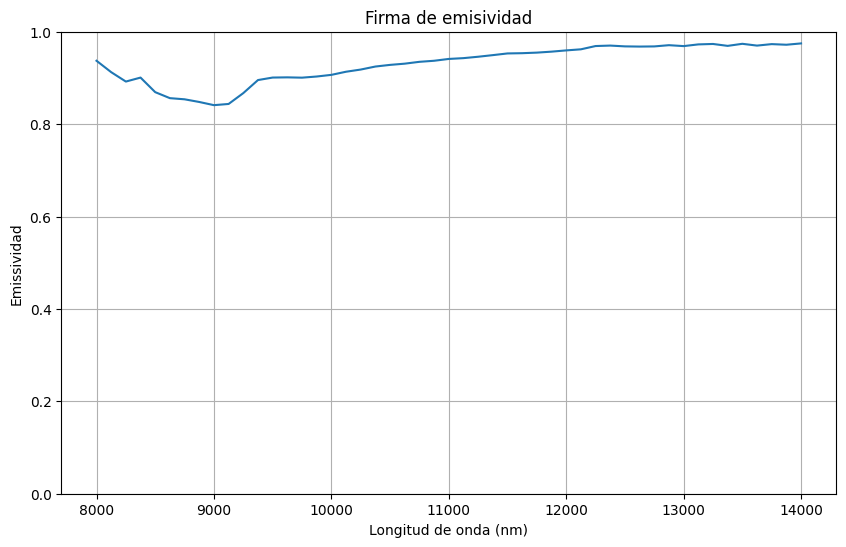

In [38]:
# Ejemplo de uso con el archivo de firma espectral
firma_path = r"C:\Users\mgefr\Documents\1UIS\proyecto-grado\assets\materials\default.txt"

firma_test = extract_spectral_values(wave_lengths, firma_path)

plt.figure(figsize=(10, 6))
plt.plot(wave_lengths, firma_test)
plt.ylim(0,1)
plt.title("Firma de emisividad")
plt.xlabel("Longitud de onda (nm)")
plt.ylabel("Emissividad")
plt.grid(True)
plt.show()


(49,)


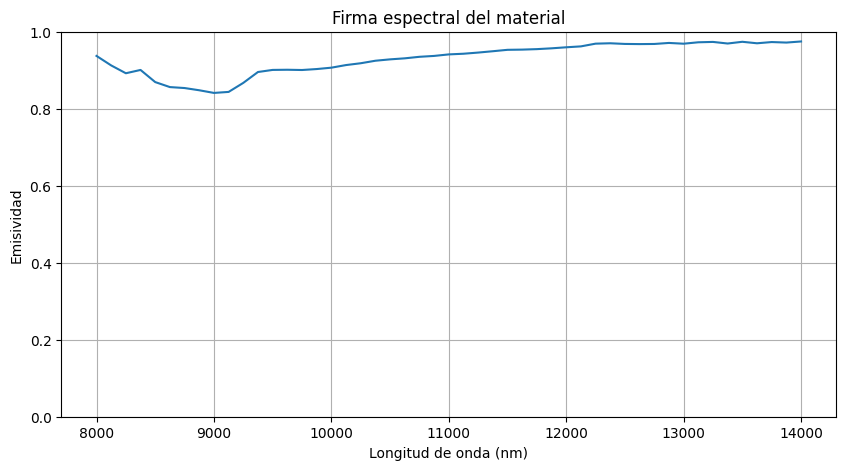

In [39]:
material = "stone"  # escoge el material que quieres
indice_material = np.where(dataBaseName == material)[0][
    0
]  # busca el indice del material en la base de datos

firma = dataBaseLib[:, indice_material]  # firma espectral del material

firma = extract_spectral_values(wave_lengths, firma_path)

# firma[24] = 0
# firma[25] = 0.5
# firma[26] = 1.0
# firma[27] = 0
# firma[28] = 0.5
# firma[29] = 1.0

print(firma.shape)

# plot
plt.figure(figsize=(10, 5))
plt.plot(wave_lengths, firma)
plt.title("Firma espectral del material")
plt.xlabel("Longitud de onda (nm)")
plt.ylabel("Emisividad")
plt.ylim(0, 1)
plt.grid()
plt.show()

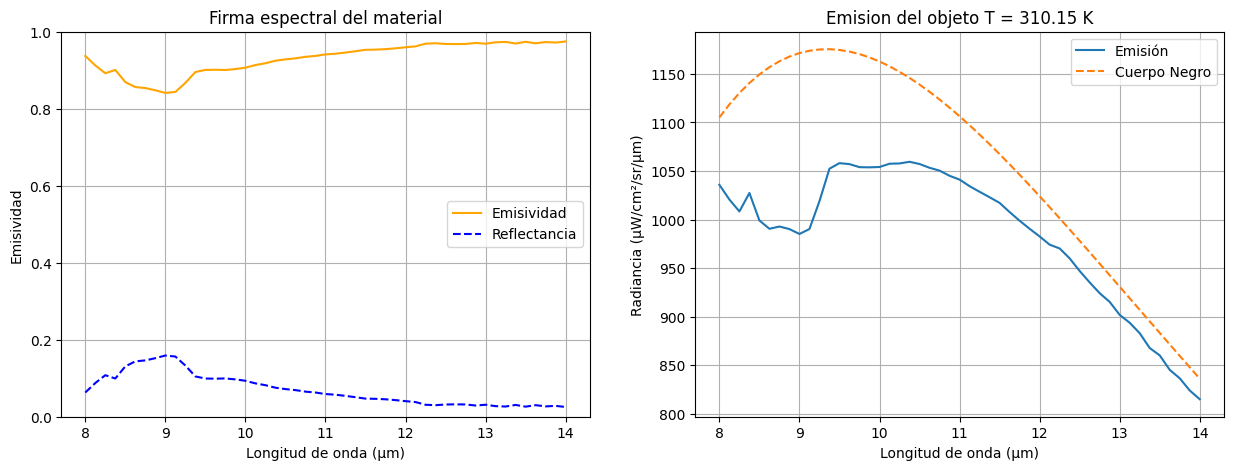

In [40]:
temperatura = 310.15  # temperatura objeto
temperatura_aire = 303.15

wave_lengths = np.linspace(8000, 14000, 49).astype(int)

black_body = blackbody_radiance_nm(wave_lengths, temperatura)  # radiancia del objeto
black_body_air = blackbody_radiance_nm(wave_lengths, temperatura_aire)  # radiancia del aire

emision = black_body * firma  # emision del objeto

reflectance = (1-firma)

# subplots
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(wave_lengths/1000, firma, label='Emisividad', color='orange')
plt.plot(wave_lengths/1000, reflectance, label='Reflectancia', color='blue', linestyle='--')
plt.title(f"Firma espectral del material")
plt.xlabel("Longitud de onda (μm)")
plt.ylabel("Emisividad")
plt.ylim(0, 1)
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(wave_lengths/1000, emision, label='Emisión')
plt.plot(wave_lengths/1000, black_body, linestyle='--', label='Cuerpo Negro')
plt.title(f"Emision del objeto T = {temperatura} K")
plt.xlabel("Longitud de onda (μm)")
plt.ylabel("Radiancia (μW/cm²/sr/μm)")
plt.grid()
plt.legend()

plt.show()


In [41]:
def lista_a_string(valores):
    return ", ".join(str(v) for v in valores)

In [42]:
dragon_emision = {
    "type": "obj",
    "filename": "Dragon.obj",
    "to_world": T().translate([0, 0, 0]),
    "emitter": {
        "type": "area",
        "radiance": {
            "type": "irregular",
            "wavelengths": lista_a_string(wave_lengths),
            "values": lista_a_string(emision),
        },
    },
}

dragon_blackbody = {
    "type": "obj",
    "filename": "Dragon.obj",
    "to_world": T().translate([0, 0, 0]),
    "emitter": {
        "type": "area",
        "radiance": {
            "type": "irregular",
            "wavelengths": lista_a_string(wave_lengths),
            "values": lista_a_string(black_body),
        },
    },
}

dragon_air = {
    "type": "obj",
    "filename": "Dragon.obj",
    "to_world": T().translate([0, 0, 0]),
    "emitter": {
        "type": "area",
        "radiance": {
            "type": "irregular",
            "wavelengths": lista_a_string(wave_lengths),
            "values": lista_a_string(black_body_air),
        },
    },
}

dragon_emision_reflectance = {
    "type": "obj",
    "filename": "Dragon.obj",
    "to_world": T().translate([0, 0, 0]),
    "bsdf": {
        "type": "diffuse",
        "reflectance": {
            "type": "irregular",
            "wavelengths": lista_a_string(wave_lengths),
            "values":      lista_a_string(reflectance),
        },
    },
    "emitter": {
        "type": "area",
        "radiance": {
            "type": "irregular",
            "wavelengths": lista_a_string(wave_lengths),
            "values": lista_a_string(emision),
        },
    },
}

## Derivación de la relación entre atenuación en dB y en forma exponencial natural

Partimos de la expresión en decibelios:

$$
10^{-\frac{a d}{10}}
$$

---

### Paso 1: Cambio de base
Usamos que $ 10^x = e^{x \ln 10} $:

$$
10^{-\frac{a d}{10}} 
= e^{\left(-\frac{a d}{10}\right)\ln 10}
= e^{-\left(\frac{\ln 10}{10}\,a\right) d}.
$$

---

### Paso 2: Comparación con la forma exponencial
La forma general en nepers es:

$$
e^{-a' d}.
$$

Al comparar:

$$
e^{-\left(\frac{\ln 10}{10}\,a\right) d} \equiv e^{-a' d},
$$

se obtiene:

$$
a' = \frac{\ln 10}{10}\,a.
$$

---

### Paso 3: Verificación por derivada
Si derivamos respecto a $d$:

$$
\frac{d}{dd}\left(10^{-\frac{a d}{10}}\right)
= \ln 10 \cdot 10^{-\frac{a d}{10}}\left(-\frac{a}{10}\right)
= -\left(\frac{\ln 10}{10}\,a\right) e^{-\left(\frac{\ln 10}{10}\,a\right)d}.
$$

Y la derivada de la forma natural:

$$
\frac{d}{dd}\left(e^{-a' d}\right) = -a' e^{-a'd}.
$$

Esto confirma que:

$$
a' = \frac{\ln 10}{10}\,a.
$$


In [43]:
def get_attenuation_for_wavelengths(wavelengths: np.ndarray, attenuation_file: str = "air") -> np.ndarray:

        wavelengths_um = wavelengths / 1000.0

        try:
            # Construir la ruta del archivo
            file_path = f"../assets/reference_data/{attenuation_file}.txt"
            
            # Cargar los datos del archivo
            trans_array = np.loadtxt(file_path)
            
            # Extraer columnas: [wavelength, transmittance, attenuation]
            file_wavelengths = trans_array[:, 0]  # Primera columna: longitudes de onda
            file_attenuation = trans_array[:, 2]  # Tercera columna: atenuación
            
            # Encontrar los índices más cercanos para cada longitud de onda deseada
            attenuation_values = []
            
            for target_wavelength in wavelengths_um:
                # Encontrar el índice del valor más cercano
                closest_index = np.argmin(np.abs(file_wavelengths - target_wavelength))
                attenuation_values.append(file_attenuation[closest_index])

            original = np.array(attenuation_values)
            
            attenuation_array = np.array(attenuation_values)

            attenuation_array = attenuation_array * (np.log(10) / 10)
            
            return [attenuation_array, original]

        except (OSError, ValueError) as e:
            raise RuntimeError("Error al obtener la atenuación") from e


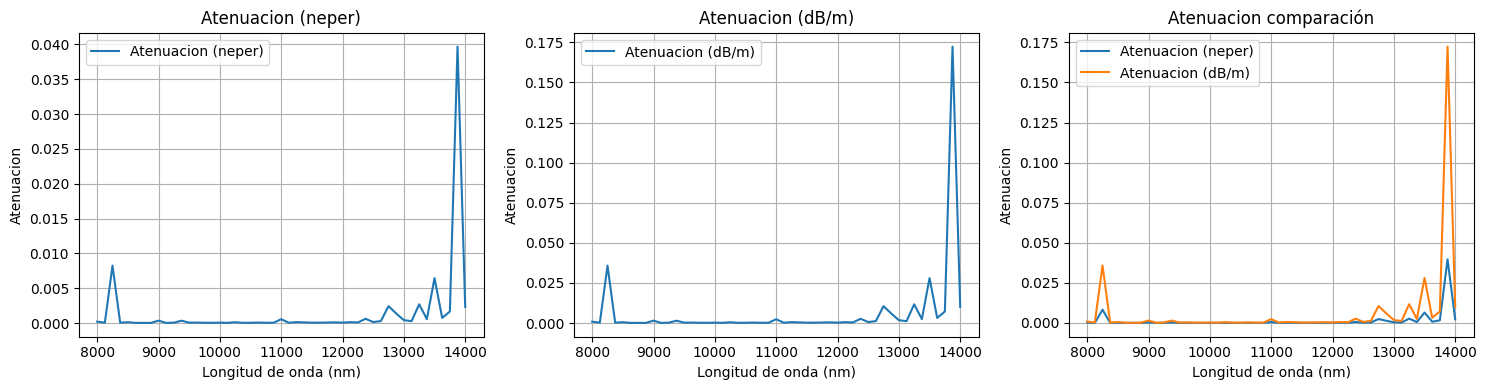

In [44]:
attenation_file = "air"
sigma_t, original_sigma_t = get_attenuation_for_wavelengths(wave_lengths, attenation_file)

# sigma_t[24] = 0
# sigma_t[25] = 0
# sigma_t[26] = 0
# sigma_t[27] = 1
# sigma_t[28] = 1
# sigma_t[29] = 1

plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.plot(wave_lengths, sigma_t, label="Atenuacion (neper)")
plt.title("Atenuacion (neper)")
plt.xlabel("Longitud de onda (nm)")
plt.ylabel("Atenuacion")
plt.grid()
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(wave_lengths, original_sigma_t, label="Atenuacion (dB/m)")
plt.title("Atenuacion (dB/m)")
plt.xlabel("Longitud de onda (nm)")
plt.ylabel("Atenuacion")
plt.grid()
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(wave_lengths, sigma_t, label="Atenuacion (neper)")
plt.plot(wave_lengths, original_sigma_t, label="Atenuacion (dB/m)")
plt.title("Atenuacion comparación")
plt.xlabel("Longitud de onda (nm)")
plt.ylabel("Atenuacion")
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()

In [45]:


niebla = {
    "type": "homogeneous",  # medio homogeneo, es decir el mismo sigma en todo el espacio,
    "id": "niebla",  # identificador del medio, para referenciarlo
    "albedo": {
        "type": "constvolume",  # textura volumétrica constante
        "value": {"type": "uniform", "value": 0.0},
    },
    "sigma_t": {
        "type": "constvolume",
        "value": {
            "type": "irregular",  # definimos un espectro
            "wavelengths": lista_a_string(wave_lengths),
            "values": lista_a_string(sigma_t),
        },
    },
    "phase": {  # define como se dispersa la luz en el medio (no la he entendido bien)
        "type": "hg",
        "g": 0.95,  # usar valores de 0.9-0.95 que es lo que pasa en el infrarrojo lejano, preguntarle al profe
        # con este nuevo valor pareciera que no existiera niebla, pero si lo pongo en 0.0 se ve la niebla
    },
}

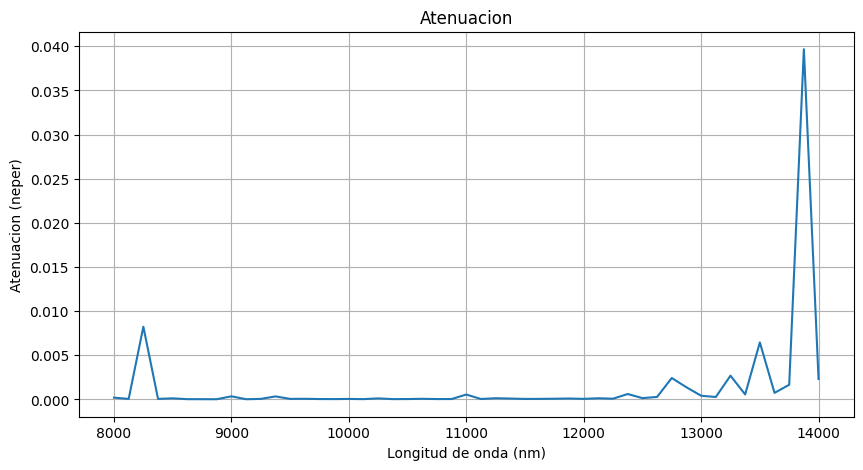

In [46]:
plt.figure(figsize=(10, 5))
plt.plot(wave_lengths, sigma_t)
plt.title("Atenuacion")
plt.xlabel("Longitud de onda (nm)")
plt.ylabel("Atenuacion (neper)")
plt.grid()
plt.show()

In [47]:
sensor_espectral_niebla = load_sensor_spectral(r, phi, theta, wave_lengths, sigma, k, n)
sensor_espectral_niebla["medium"] = {"type": "ref", "id": "niebla"}

sensor_espectral_sin_niebla = load_sensor_spectral(
    r, phi, theta, wave_lengths, sigma, k, n
)

sensor_depth = load_sensor_depth(r, phi, theta)

In [48]:
integrador_niebla = {"type": "volpathmis", "max_depth": 8}

integrador_sin_niebla = {"type": "path"}

In [49]:
scene_sin_niebla = mi.load_dict(
    {
        "type": "scene",
        "integrator": integrador_sin_niebla,
        "sensor": sensor_espectral_sin_niebla,
        "dragon": dragon_emision,
    }
)

scene_niebla = mi.load_dict(
    {
        "type": "scene",
        "integrator": integrador_niebla,
        "niebla": niebla,
        "sensor": sensor_espectral_niebla,
        "dragon": dragon_emision,
    }
)
scene_depth = mi.load_dict(
    {
        "type": "scene",
        "integrator": {
            "type": "depth",
        },
        "sensor": sensor_depth,
        "dragon": dragon_emision,
    }
)

scene_sin_niebla_reflectance = mi.load_dict(
    {
        "type": "scene",
        "integrator": integrador_sin_niebla,
        "sensor": sensor_espectral_sin_niebla,
        "dragon": dragon_emision_reflectance,
        "emitter": {
            "type": "constant",
            "radiance": {
                "type": "irregular",
                "wavelengths": lista_a_string(wave_lengths),
                "values": lista_a_string(black_body_air),
            },
        },
    }
)

scene_niebla_reflectance = mi.load_dict(
    {
        "type": "scene",
        "integrator": integrador_niebla,
        "niebla": niebla,
        "sensor": sensor_espectral_niebla,
        "dragon": dragon_emision_reflectance,
        "emitter": {
            "type": "constant",
            "radiance": {
                "type": "irregular",
                "wavelengths": lista_a_string(wave_lengths),
                "values": lista_a_string(black_body_air),
            },
        },
    }
)

In [50]:
#imagen_niebla = mi.render(scene_niebla, spp=spp)
#imagen_sin_niebla = mi.render(scene_sin_niebla, spp=spp)
#imagen_depth = mi.render(scene_depth, spp=spp)
#imagen_niebla_reflectance = mi.render(scene_niebla_reflectance, spp=spp)
#imagen_sin_niebla_reflectance = mi.render(scene_sin_niebla_reflectance, spp=spp)

In [51]:
def RMSE (array1, array2):
    return np.sqrt(np.mean((array1 - array2) ** 2))

def NRMSE (array1, array2):
    return RMSE(array1, array2) / (np.max(array2) - np.min(array2))

In [52]:
lista_temperaturas = [250, 270, 290, 310, 330, 350]
colores = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
bs = []
emissions = []
lista_dicts = []
lista_scenas = []
lista_resultados = []

In [53]:
wave_lengths = np.linspace(8000, 14000, 49).astype(int)

spp = 1024 * 16 
x = 200
y = 250

In [54]:
for temperatura in lista_temperaturas:
    black_body = blackbody_radiance_nm(wave_lengths, temperatura)  # radiancia del objeto
    emision = black_body * firma  # emision del objeto
    reflectance = (1-firma)

    bs.append(black_body)
    emissions.append(emision)

    dragon_emision = {
    "type": "obj",
    "filename": "Dragon.obj",
    "to_world": T().translate([0, 0, 0]),
    "emitter": {
        "type": "area",
        "radiance": {
            "type": "irregular",
            "wavelengths": lista_a_string(wave_lengths),
            "values": lista_a_string(emision),
        },      
    },
    }

    lista_dicts.append(dragon_emision)

    lista_scenas.append(
        mi.load_dict(
        {
            "type": "scene",
            "integrator": integrador_sin_niebla,
            "sensor": sensor_espectral_sin_niebla,
            "dragon": dragon_emision,
        }
    ))


In [55]:
for i , scena in enumerate(lista_scenas):
    print(f"Renderizando escena {i}...")
    lista_resultados.append(mi.render(scena, spp=spp))
    print(f"Escena {i} renderizada.")
    print()

Renderizando escena 0...
Escena 0 renderizada.

Renderizando escena 1...
Escena 1 renderizada.

Renderizando escena 2...
Escena 2 renderizada.

Renderizando escena 3...
Escena 3 renderizada.

Renderizando escena 4...
Escena 4 renderizada.

Renderizando escena 5...
Escena 5 renderizada.



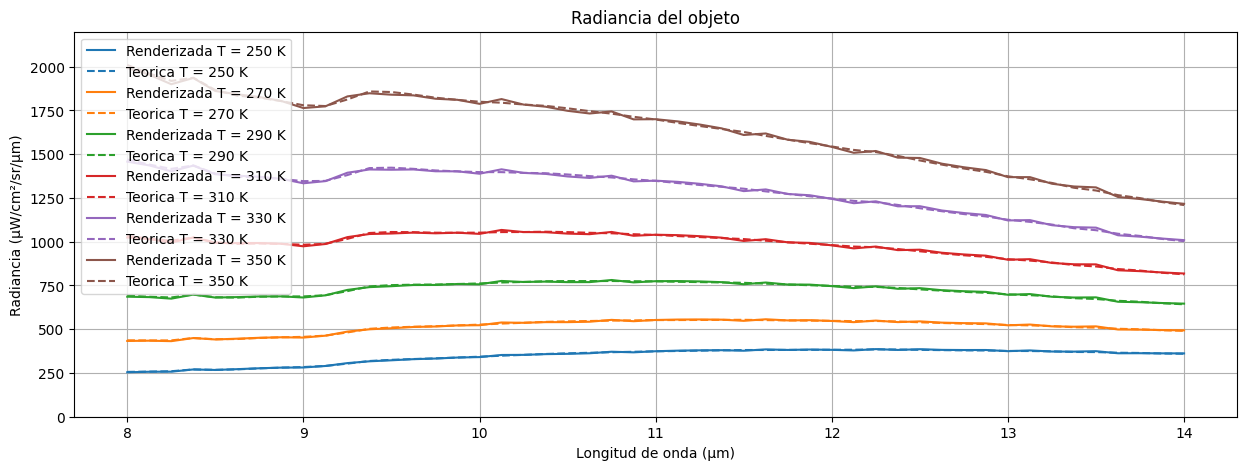

In [56]:
plt.figure(figsize=(15, 5))


for i, resultado in enumerate(lista_resultados):
    plt.plot(wave_lengths/1000, resultado[y,x,:], color=colores[i], label=f'Renderizada T = {lista_temperaturas[i]} K')
    plt.plot(wave_lengths/1000, emissions[i], linestyle='--', color=colores[i], label=f'Teorica T = {lista_temperaturas[i]} K')
    
plt.title("Radiancia del objeto")
plt.xlabel("Longitud de onda (μm)")
plt.ylabel("Radiancia (μW/cm²/sr/μm)")
plt.ylim(0, 2200)
plt.grid()
plt.legend()
plt.show()

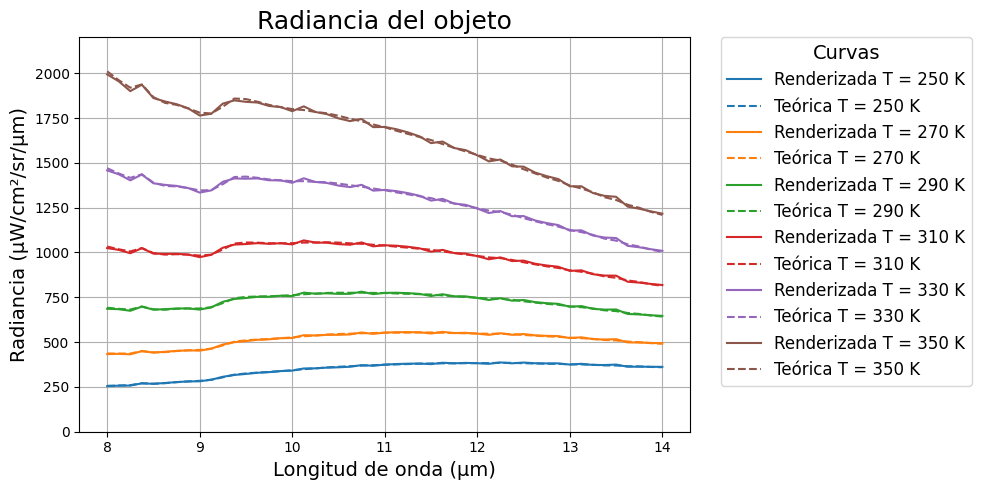

In [57]:
plt.figure(figsize=(10, 5))  # más corta (antes era 15x5)

for i, resultado in enumerate(lista_resultados):
    plt.plot(wave_lengths/1000, resultado[y, x, :],
             color=colores[i], label=f'Renderizada T = {lista_temperaturas[i]} K')
    plt.plot(wave_lengths/1000, emissions[i],
             linestyle='--', color=colores[i], label=f'Teórica T = {lista_temperaturas[i]} K')

plt.title("Radiancia del objeto", fontsize=18)        # título más grande
plt.xlabel("Longitud de onda (μm)", fontsize=14)     # eje X más grande
plt.ylabel("Radiancia (μW/cm²/sr/μm)", fontsize=14)  # eje Y más grande
plt.ylim(0, 2200)
plt.grid()

# leyenda afuera a la derecha, con texto más grande
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left",
           borderaxespad=0., fontsize=12, title="Curvas", title_fontsize=14)

plt.tight_layout()
plt.show()


In [58]:
# Cálculo de errores (RMSE) por temperatura en el píxel (y, x)
if not (len(lista_resultados) == len(emissions) == len(lista_temperaturas)):
    raise ValueError("Listas de resultados, emisiones y temperaturas con longitudes inconsistentes.")

errores_rmse = []
errores_relativos = []

for i, res in enumerate(lista_resultados):
    rmse_val = RMSE(res[y, x, :], emissions[i])
    errores_rmse.append(rmse_val)
    
    # Error relativo respecto al valor máximo de la curva teórica
    err_rel = NRMSE(res[y, x, :], emissions[i]) * 100
    errores_relativos.append(err_rel)

errores_rmse = np.array(errores_rmse)
errores_relativos = np.array(errores_relativos)

# índices de min y max
idx_max = int(np.argmax(errores_rmse))
idx_min = int(np.argmin(errores_rmse))

# valores extremos y promedio
error_max = float(errores_rmse[idx_max])
temp_max = lista_temperaturas[idx_max]

error_min = float(errores_rmse[idx_min])
temp_min = lista_temperaturas[idx_min]

error_promedio = float(np.mean(errores_rmse))
error_rel_prom = float(np.mean(errores_relativos))

# impresión de resultados
print("Errores (RMSE) por temperatura:")
for t, e, er in zip(lista_temperaturas, errores_rmse, errores_relativos):
    print(f"T = {t} K -> RMSE = {e:.6f} ({er:.4f} %)")

print(f"\nMáximo RMSE: {error_max:.6f} a T = {temp_max} K")
print(f"Mínimo RMSE: {error_min:.6f} a T = {temp_min} K")
print(f"RMSE promedio: {error_promedio:.6f}")
print(f"Error relativo promedio: {error_rel_prom:.4f} %")


Errores (RMSE) por temperatura:
T = 250 K -> RMSE = 2.262340 (1.7577 %)
T = 270 K -> RMSE = 3.322439 (2.8159 %)
T = 290 K -> RMSE = 4.658147 (3.4999 %)
T = 310 K -> RMSE = 6.286823 (2.5823 %)
T = 330 K -> RMSE = 8.221042 (1.7614 %)
T = 350 K -> RMSE = 10.465022 (1.3071 %)

Máximo RMSE: 10.465022 a T = 350 K
Mínimo RMSE: 2.262340 a T = 250 K
RMSE promedio: 5.869302
Error relativo promedio: 2.2874 %
